### Logistic Regression
###### 회귀를 해서 나온 결과(X * W + b)를 sigmoid함수에 넣어서 0~1 사이의 값이 나오게 한다.(확률) 즉, 분류문제에 회기가 쓰인다.

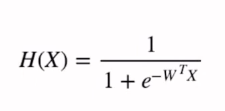

#### Logistic function으로 위와 같은 sigmoid 함수를 사용한다.

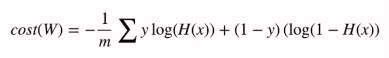

#### loss function으로는 NNL을 사용한다.

In [6]:
# nn.Module을 이용하여 실전에서처럼 구현 할 때 코드
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class BinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x)) # __call__() 덕분에 함수가 아니라 호출 처럼만 해도 사용할 수 있다.

x_train = torch.FloatTensor([[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]])
y_train = torch.FloatTensor([[0], [0], [0], [1], [1], [1]])


model = BinaryClassifier()

optimizer = optim.SGD(model.parameters(), lr = 1)

nb_epochs = 100

for epoch in range(nb_epochs + 1):

    hypothesis = model(x_train)

    cost = F.binary_cross_entropy(hypothesis, y_train) # 이진 분류를 위해 NNL을 전개한 loss function

    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    if epoch % 10 == 0:
        prediction = hypothesis >= torch.FloatTensor([0.5])
        correct_prediction = prediction.float() == y_train
        accuracy = correct_prediction.sum().item() / len(correct_prediction)
        print('Epoch {:4d}/{} Cost: {:.6f} Accuracy {:2.2f}%'.format(epoch, nb_epochs, cost.item(),accuracy * 100 ))




Epoch    0/100 Cost: 0.667090 Accuracy 50.00%
Epoch   10/100 Cost: 0.488461 Accuracy 66.67%
Epoch   20/100 Cost: 0.403797 Accuracy 83.33%
Epoch   30/100 Cost: 0.341819 Accuracy 83.33%
Epoch   40/100 Cost: 0.288873 Accuracy 83.33%
Epoch   50/100 Cost: 0.241123 Accuracy 100.00%
Epoch   60/100 Cost: 0.198676 Accuracy 100.00%
Epoch   70/100 Cost: 0.166906 Accuracy 100.00%
Epoch   80/100 Cost: 0.149456 Accuracy 100.00%
Epoch   90/100 Cost: 0.138649 Accuracy 100.00%
Epoch  100/100 Cost: 0.129586 Accuracy 100.00%
